In [1]:
from typing import TypedDict, Literal

class Portfoliostate(TypedDict):
    amount_usd: float
    total_usd : float
    currency : Literal['EUR', 'INR']
    total : float

In [5]:
# Create nodes

def cal_amount_usd(state : Portfoliostate) -> Portfoliostate:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def cal_total_inr(state : Portfoliostate) -> Portfoliostate:
    state['total'] = state['total_usd'] * 82.0
    return state

def cal_total_eur(state : Portfoliostate) -> Portfoliostate:
    state['total'] = state['total_usd'] * 0.9
    return state

def check_currency(state : Portfoliostate) -> str:
    return state['currency']

In [8]:
# Nodes and Edges

from langgraph.graph import StateGraph, START, END

builder = StateGraph(Portfoliostate)

builder.add_node('cal_amt_usd', cal_amount_usd)
builder.add_node('cal_total_inr', cal_total_inr)
builder.add_node('cal_total_eur', cal_total_eur)

builder.add_edge(START, 'cal_amt_usd')
builder.add_conditional_edges('cal_amt_usd', check_currency, {
    'INR': 'cal_total_inr',
    'EUR': 'cal_total_eur'
})
builder.add_edge('cal_total_inr', END)
builder.add_edge('cal_total_eur', END)

graph = builder.compile()

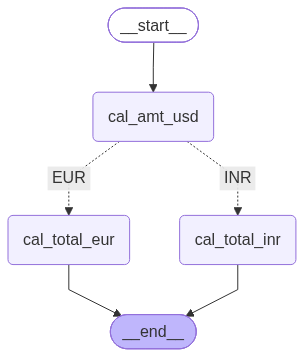

In [9]:
# Visulaize the graph
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
intial_state = Portfoliostate({ "amount_usd": 100, "total_usd": 0, "currency": "EUR", "total": 0 })
graph.invoke(intial_state)

{'amount_usd': 100, 'total_usd': 108.0, 'currency': 'EUR', 'total': 97.2}

In [12]:
intial_state = Portfoliostate({ "amount_usd": 100, "total_usd": 0, "currency": "INR", "total": 0 })
graph.invoke(intial_state)

{'amount_usd': 100, 'total_usd': 108.0, 'currency': 'INR', 'total': 8856.0}